In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import torch
from llms.llm_ochestrator import LLMOchestrator

torch.manual_seed(123)
ochestrator = LLMOchestrator("gpt2-small", "basic")
ochestrator.model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=76

In [10]:
text = ochestrator.generate_text("Every effort moves you", max_new_tokens=15)
print(text)

Every effort moves you rentingetic wasnم refres RexMeCHicular stren Mortgage TT remember gard ACTIONS


In [11]:
train_loader, val_loader, test_loader = ochestrator.create_plantext_dataloader(file_path="./training_data/the-verdict.txt",
                                                                               train_ratio=0.9,
                                                                               validation_ratio=0.1,
                                                                               batch_size=2)

In [12]:
num_epochs = 15
train_losses, val_losses, track_tokens_seen, track_lrs = ochestrator.train_model_by_plantext(num_epochs=num_epochs,
                                    start_context="Every effort moves you",
                                    train_loader=train_loader,
                                    validation_loader=val_loader,
                                    batch_size=2)


Ep 1 (Step 000000): Train loss 10.857, Val loss 10.854
Ep 1 (Step 000005): Train loss 9.491, Val loss 9.712
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Step 000010): Train loss 8.654, Val loss 8.894
Ep 2 (Step 000015): Train loss 7.720, Val loss 8.019
Every effort moves you the                                                 
Ep 3 (Step 000020): Train loss 6.728, Val loss 7.118
Ep 3 (Step 000025): Train loss 5.982, Val loss 6.633
Every effort moves you, the, the, the, the, the, the, the, the,, the,, the,, the, the, the the, the, the, the, the, the, the, the, the, the, the
Ep 4 (Step 000030): Train loss 5.550, Val loss 6.534
Ep 4 (Step 000035): Train loss 4.963, Val loss 6.403
Every effort moves you in the ""I had"I he had been a--I had been, and I had been the  "I had a I had been the of the I had been the I had the of the "I had been I
Ep 5 (Step 000040): Train loss 4.394, Val loss 6.248
Every effort moves you know it was not to the picture--I to the

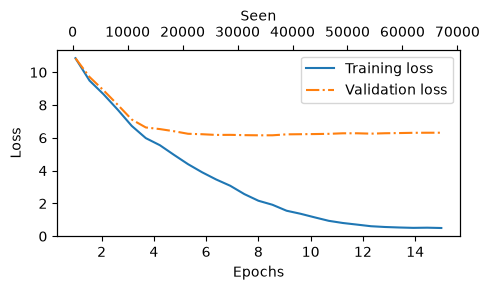

In [13]:
ochestrator.plot_losses()

In [ ]:
torch.manual_seed(123)
text = ochestrator.generate_text("Every effort moves you", max_new_tokens=15)
print(text)

Every effort moves you?"




I glanced after him, struck by his last


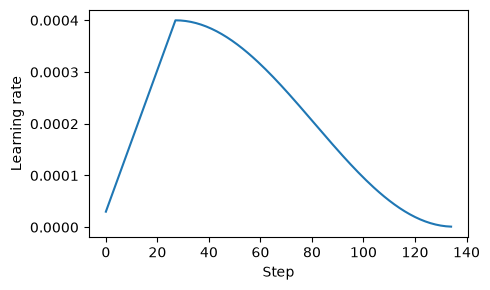

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.ylabel("Learning rate")
plt.xlabel("Step")
total_training_steps = len(train_loader) * num_epochs
plt.plot(range(total_training_steps), track_lrs)
plt.tight_layout(); 
plt.show()